# Logistic Regression

| Date | Who | Mail |  What |
| ---  | --- | ---  | ---   |     
| Mar 17, 2026 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Initial code created using Gemini 3.0 |
| Mar 17, 2026 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Code, formulation and comments improvements |

Logistic Regression, a classification algorithm. We will apply it to the Iris dataset.


## 1. Setting Up Our Environment and Data

First, we will load our dataset. We will download the Iris dataset, which contains 150 samples of flowers across 3 classes, with 4 features each. For visualization purposes, we will only use the first two features (Sepal Length and Sepal Width).

In [233]:
import urllib.request
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# 1. Fetch the Iris dataset https://archive.ics.uci.edu/dataset/53/iris
# Variable
# 0: sepal length [cm]
# 1: sepal width  [cm]
# 2: petal length [cm]
# 3: petal width  [cm]
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
response = urllib.request.urlopen(url)
data = response.read().decode('utf-8').strip().split('\n')

# 2. Parse features and labels
X_raw = []
t_raw = []
class_mapping = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}

for line in data:
    if line:
        parts = line.split(',')
        X_raw.append([float(parts[0]), float(parts[1])]) # Only taking first 2 features for 2D plotting
        t_raw.append(class_mapping[parts[4]])

# X represents our input matrix (N x D)
# t represents our target vectors
X = np.array(X_raw)
t = np.array(t_raw)

# 3. Data Standardization
X_mean = np.mean(X, axis=0)
X_std  = np.std( X, axis=0)
X_norm = (X - X_mean)/X_std

# 4. Feature Space Mapping \phi(x)
# We add a column of 1s to represent the bias term w_0.
# We map input x to feature space \phi(x).
# Here, \phi(x) = [1, x_1, x_2]^T
N = X_norm.shape[0]
Phi = np.c_[np.ones(N), X_norm] # Shape: (150, 3)

print(fr"Design matrix \Phi shape: {Phi.shape}")
print(f"Target vector t shape: {t.shape}")

Design matrix \Phi shape: (150, 3)
Target vector t shape: (150,)


## 2. Multiclass Logistic Regression: The Theory

In linear regression, we predict a continuous value. In classification, we want to predict the probability that a sample belongs to a specific class $C_k$.

For $K$ classes, we use the **softmax function** (the multiclass generalization of the logistic sigmoid). The probability that observation $n$ belongs to class $k$, denoted as $y_{nk}$, is given by:

$$y_{nk} = p(C_k | \boldsymbol{\phi}_n) = \frac{\exp(a_{nk})}{\sum_{j=1}^K \exp(a_{nj})}$$

Where $a_{nk}$ is the linear activation for class $k$:


$$a_{nk} = \boldsymbol{w}_k^T \boldsymbol{\phi}_n$$

* $\boldsymbol{\phi}_n$ is our feature vector for sample $n$ (including the bias).
* $\boldsymbol{w}_k$ is the weight vector for class $k$.


In [234]:
def softmax(A):
    """
    Computes the softmax for matrix A of shape (N, K).
    Includes a numerical stability trick: subtracting the max.
    """
    A_max = np.max(A, axis=1, keepdims=True)
    exp_A = np.exp(A - A_max)
    return exp_A/np.sum(exp_A, axis=1, keepdims=True)


### The Error Function

To train this model, we need to minimize the error. We use the negative log-likelihood, known as the **cross-entropy error function**:

$$E(\boldsymbol{w}_1, \dots, \boldsymbol{w}_K) = - \sum_{n=1}^N \sum_{k=1}^K t_{nk} \ln y_{nk}$$

Here, $t_{nk}$ is our target represented in a "1-of-K" (one-hot) coding scheme. If sample $n$ belongs to class 2 out of 3, $\boldsymbol{t}_n = [0, 1, 0]^T$.

In [235]:
def to_one_hot(t, K):
    """Converts 1D target array to 1-of-K coding matrix."""
    N = len(t)
    T = np.zeros((N, K))
    T[np.arange(N), t] = 1
    return T


### The Gradient

To find the weights that minimize the error, we take the derivative of $E$ with respect to the weights $\boldsymbol{w}_k$:

$$\nabla_{\mathbf{w}_k} E = \sum_{n=1}^N (y_{nk} - t_{nk}) \boldsymbol{\phi}_n$$

We will update our weights iteratively using **Gradient Descent**:


$$\boldsymbol{w}_k^{(\tau+1)} = \boldsymbol{w}_k^{(\tau)} - \eta \nabla_{\boldsymbol{w}_k} E$$

where $\eta$ is our learning rate.



## 3. Multiclass Logistic Regression: Implementation

In [236]:
# Initialization of variables
np.random.seed(42)
K = 3                      # Number of classes
M = Phi.shape[1]           # Number of features (including bias)
W = np.zeros((M, K))       # Weight matrix (M x K)
T = to_one_hot(t, K)       # Target matrix (N x K)

# Hyperparameters
eta    = 0.01             # Learning rate
epochs = 1000
losses = np.zeros(epochs)
tol    = 1e-3              # Tolerance for convergence

# Gradient Descent Training Loop
for epoch in range(epochs):
    # 1. Forward pass: compute activations and predictions
    A = Phi @ W            # Shape: (N, K)
    Y = softmax(A)         # Shape: (N, K)

    # 2. Compute Cross-Entropy Loss (for monitoring convergence)
    # Add a small epsilon to log to prevent log(0)
    loss = -np.sum(T * np.log(Y + 1e-15))
    losses[epoch] = loss

    # Check for convergence
    if epoch > 0 and abs(losses[epoch-1] - losses[epoch]) < tol:
        print(f"Converged at epoch {epoch}!")
        losses = losses[:epoch+1] # Truncate losses to actual epochs run
        break

    # 3. Compute Gradient
    # \nabla E = \Phi^T (Y - T)
    Gradient = Phi.T @ (Y - T) # Shape: (M, K)

    # 4. Update Weights
    W -= eta*Gradient

print("Training Complete!")


Converged at epoch 832!
Training Complete!


Calculate now the accuracy of the classifier:

In [237]:
# 1. Compute activations for all samples
A = Phi @ W

# 2. Get the predicted class (the one with the highest activation/probability)
y_pred = np.argmax(A, axis=1)

# 3. Calculate accuracy
accuracy = 100*np.mean(y_pred == t)
print(f"Logistic Regression Accuracy: {accuracy:.2f}%")

Logistic Regression Accuracy: 83.33%


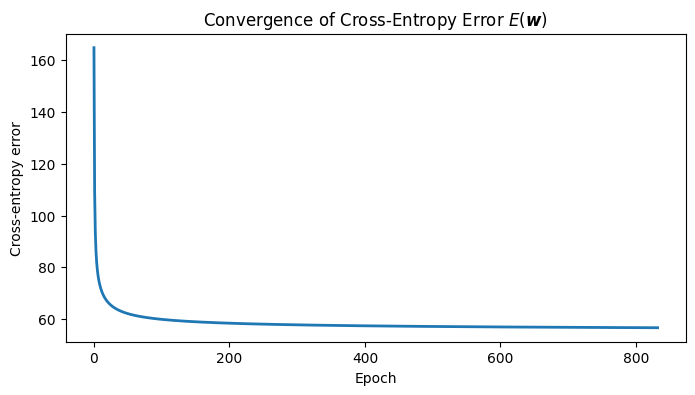

In [238]:
# Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(losses, linewidth=2)
plt.title(r'Convergence of Cross-Entropy Error $E(\boldsymbol{w})$')
plt.xlabel(r'Epoch')
plt.ylabel('Cross-entropy error')
#plt.xscale('log') # Set x-axis to log scale
#plt.yscale('log') # Set y-axis to log scale
plt.show()

### Visualizing the Decision Boundary

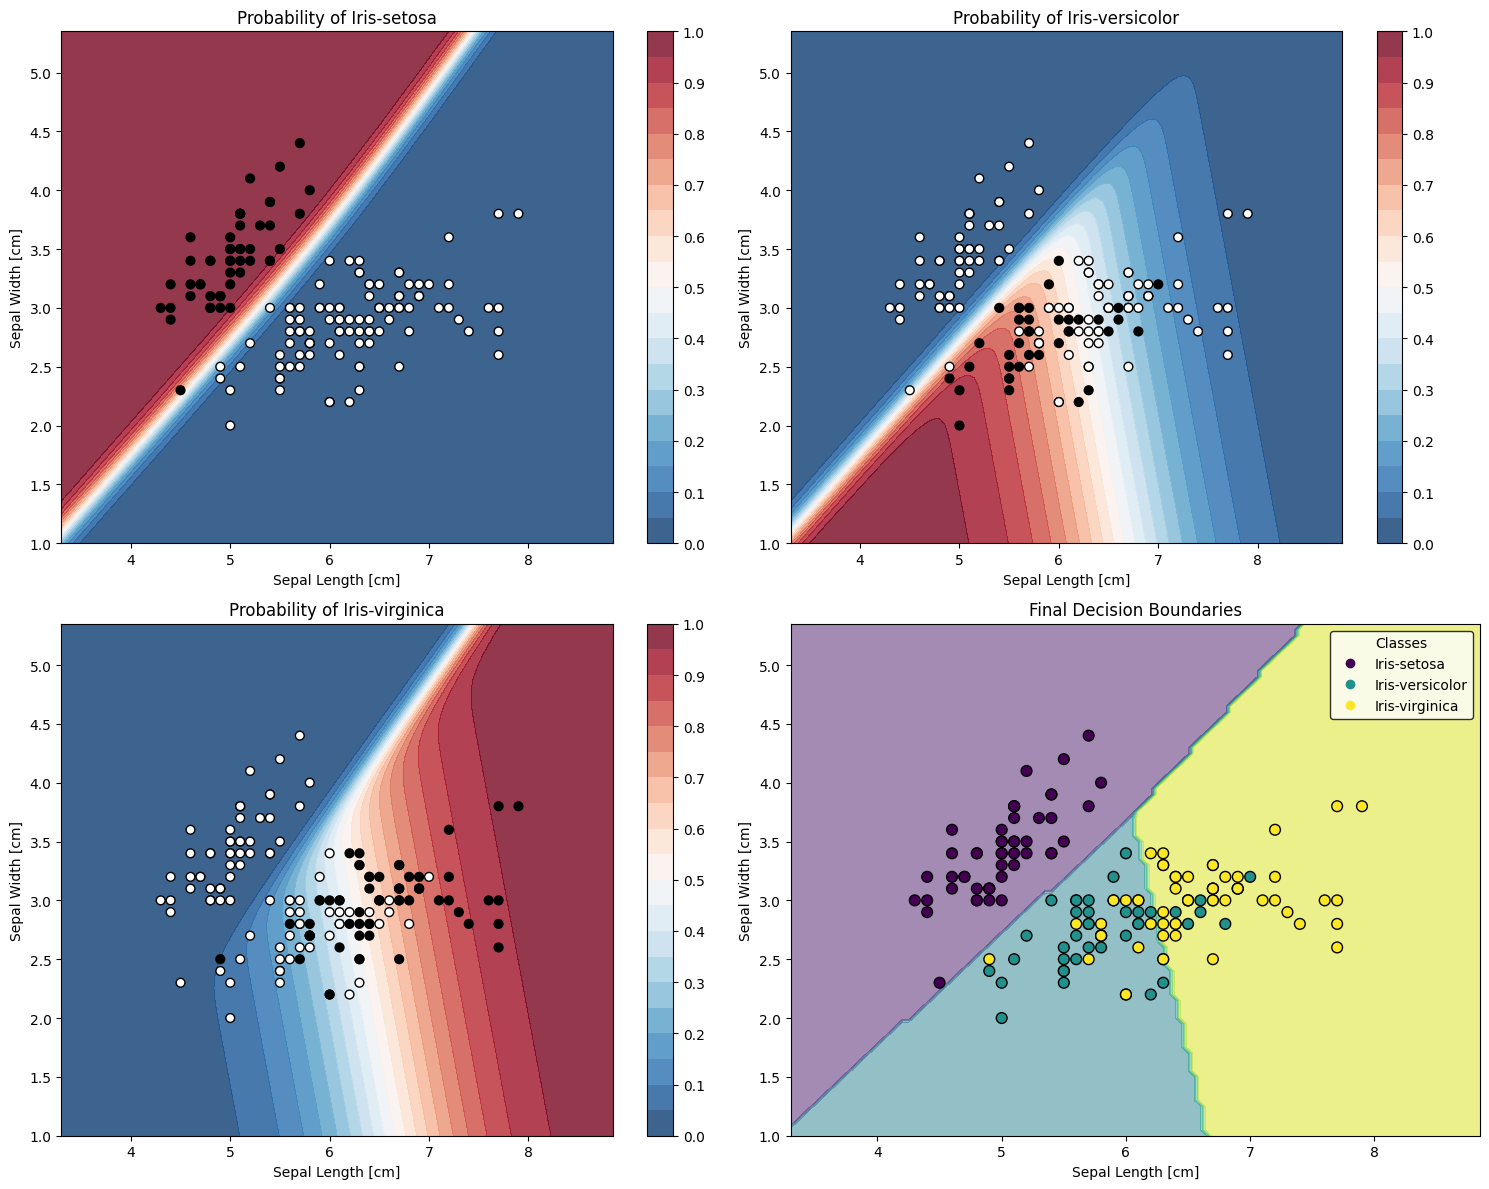

In [239]:
def plot_decision_boundary(X, t, W, X_mean, X_std, class_mapping):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))

    # Prepare grid data
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_norm = (grid_points - X_mean)/X_std
    grid_Phi = np.c_[np.ones(grid_norm.shape[0]), grid_norm]

    # Predict probabilities and classes
    Probs   = softmax(grid_Phi @ W) # Shape: (grid_size, 3)
    Z_class = np.argmax(Probs, axis=1).reshape(xx.shape)

    named_labels = sorted(class_mapping, key=class_mapping.get)

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    # 1. Plot individual class probabilities
    for i in range(3):
        Z_prob = Probs[:, i].reshape(xx.shape)
        # Fixed range for probability from 0 to 1
        contour = axes[i].contourf(xx, yy, Z_prob, levels=np.linspace(0, 1, 21), cmap='RdBu_r', alpha=0.8)
        axes[i].scatter(X[:, 0], X[:, 1], c=(t==i), edgecolors='k', cmap='binary', s=40)
        axes[i].set_title(f'Probability of {named_labels[i]}')
        cbar = fig.colorbar(contour, ax=axes[i], ticks=np.linspace(0, 1, 11))

    # 2. Plot Decision Boundary in the 4th subplot
    axes[3].contourf(xx, yy, Z_class, alpha=0.5, cmap='viridis')
    scatter = axes[3].scatter(X[:, 0], X[:, 1], c=t, edgecolors='k', cmap='viridis', s=60)
    axes[3].set_title('Final Decision Boundaries')

    handles, _ = scatter.legend_elements()
    axes[3].legend(handles, named_labels, title="Classes", frameon=True, edgecolor='black')

    for ax in axes:
        ax.set_xlabel('Sepal Length [cm]')
        ax.set_ylabel('Sepal Width [cm]')

    plt.tight_layout()
    plt.show()

plot_decision_boundary(X, t, W, X_mean, X_std, class_mapping)

## 4. Using Scikit-Learn for Logistic Regression

While implementing the algorithm from scratch is excellent for understanding the underlying math (like the softmax function and gradient descent), in practice, we usually use optimized libraries.

Below, we use `scikit-learn` to perform the same multiclass classification. This library handles the design matrix creation, standardization, and optimization internally with highly efficient solvers.

In [240]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Prepare data (using the original X and t from earlier cells)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Initialize and train the model
model = LogisticRegression(max_iter=epochs, penalty=None, tol=tol)
model.fit(X_scaled, t)

print(f"Sklearn Model Accuracy: {100*model.score(X_scaled, t):.2f}%")

Sklearn Model Accuracy: 83.33%


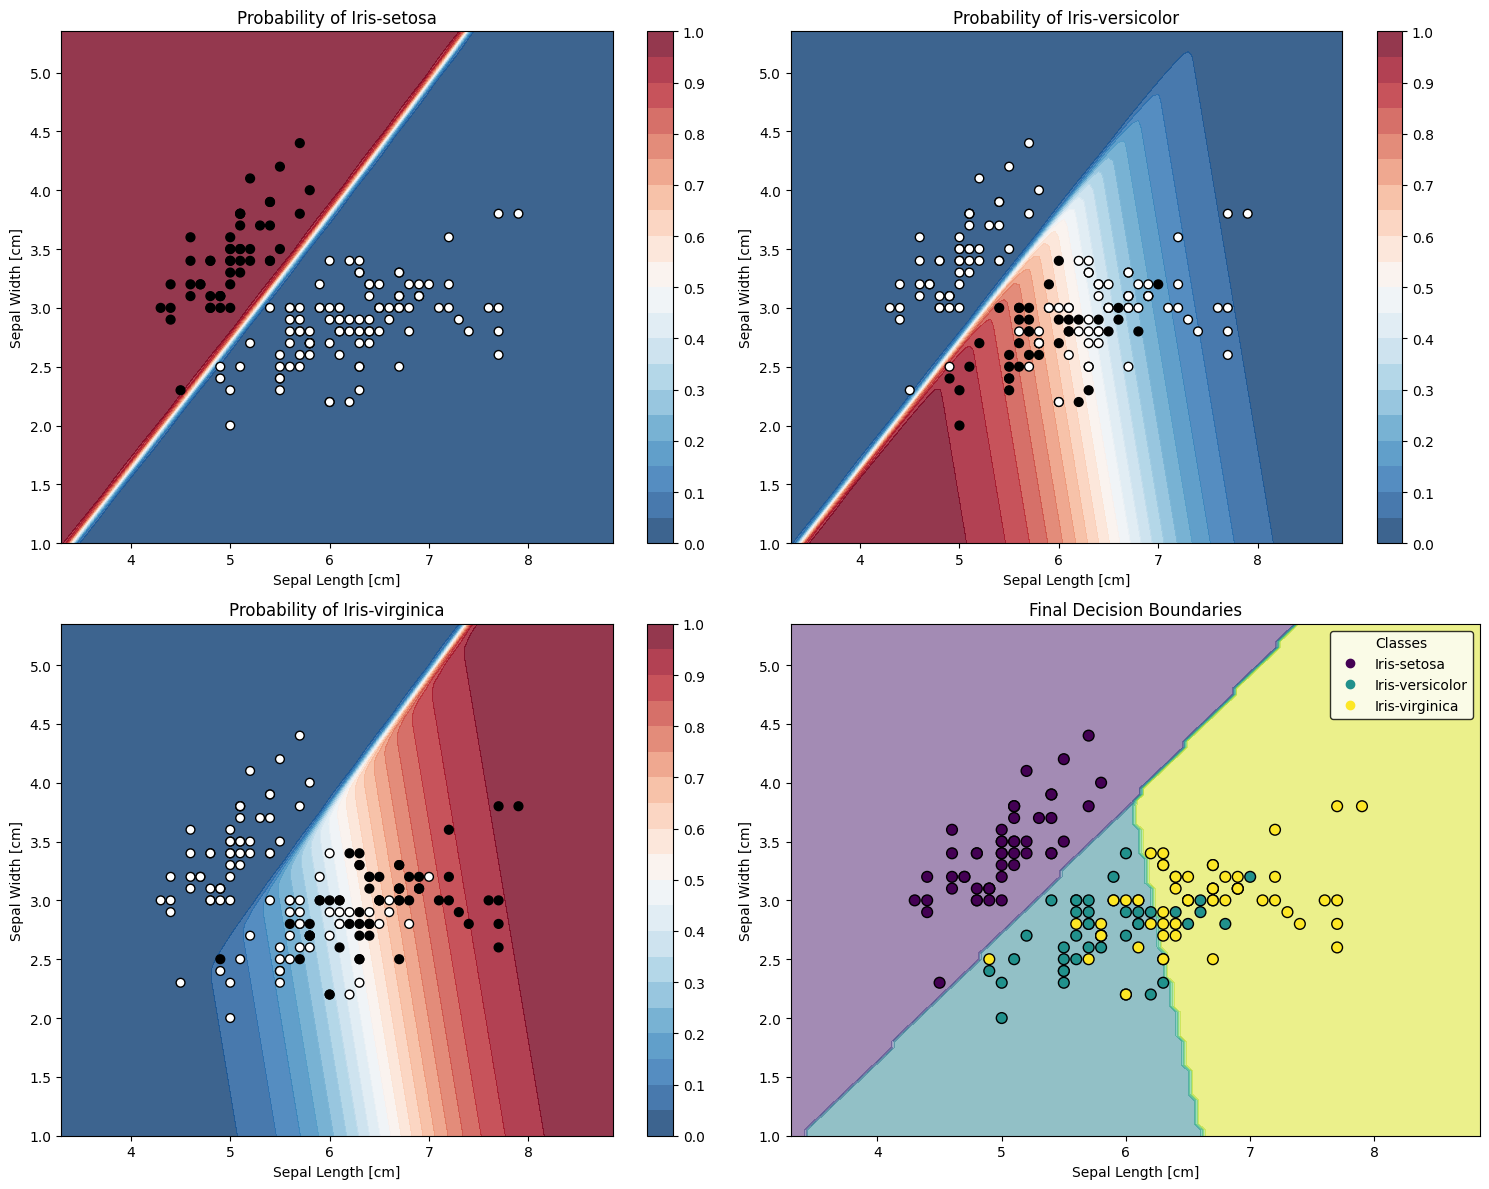

In [241]:
# 3. Extract weights for visualization
# sklearn stores weights as (K, M). We transpose to (M, K) to match our previous 'W'
# and separate intercept_ (bias) and coef_ (slopes)
W_sklearn = np.vstack([model.intercept_, model.coef_.T])

# 4. Visualize using the previously defined plotting function
plot_decision_boundary(X, t, W_sklearn, scaler.mean_, scaler.scale_, class_mapping)